In [1]:
from sympy import primerange
import json

# Generate primes up to a large limit
n = 10**7
primes = list(primerange(1, n))

# Save primes to JSON file
with open('primes.json', 'w') as f:
    json.dump(primes, f)

print(f"Generated {len(primes)} primes up to {n}.")


Generated 664579 primes up to 10000000.


In [2]:
import json

# Load primes from JSON file
with open('primes.json', 'r') as f:
    primes = json.load(f)

# Compute prime gaps
gaps = [primes[i+1] - primes[i] for i in range(len(primes) - 1)]

# Save gaps to JSON file
with open('prime_gaps.json', 'w') as f:
    json.dump(gaps, f)

print(f"Computed {len(gaps)} prime gaps.")


Computed 664578 prime gaps.


In [3]:
# Find twin primes
twin_primes = [(primes[i], primes[i+1]) for i in range(len(primes) - 1) if primes[i+1] - primes[i] == 2]

# Save twin primes to JSON file
with open('twin_primes.json', 'w') as f:
    json.dump(twin_primes, f)

print(f"Found {len(twin_primes)} twin primes.")


Found 58980 twin primes.


In [5]:
import numpy as np
import json

# Load primes
with open('primes.json', 'r') as f:
    primes = json.load(f)

# Convert primes to a NumPy array
primes = np.array(primes)

# Compute S(n) and ΔS/Δn
S = np.cumsum(np.log(primes))
delta_S = np.diff(S)  # Approximation of ΔS/Δn
n_values = primes[:-1]  # Corresponding n values for ΔS/Δn

# Save results to JSON
results = {'n': n_values.tolist(), 'S(n)': S.tolist(), 'ΔS/Δn': delta_S.tolist()}
with open('imax_analysis.json', 'w') as f:
    json.dump(results, f)

print("Saved I_max analysis.")


Saved I_max analysis.


In [12]:
import json

# Load data
with open('imax_analysis.json', 'r') as f:
    data = json.load(f)

# Extract values
n_values = data['n']
S_values = data['S(n)']
delta_S_values = data['ΔS/Δn']

print(f"Loaded {len(n_values)} prime data points.")
print(f"Loaded {len(S_values)} S(n) points.")
print(f"Loaded {len(delta_S_values)} ΔS/Δn points.")

Loaded 664578 prime data points.
Loaded 664579 S(n) points.
Loaded 664578 ΔS/Δn points.


In [13]:
# Align dimensions
S_values = S_values[:len(n_values)]  # Trim S(n) to match n
# Verify lengths
assert len(n_values) == len(S_values), "Mismatch in lengths of n and S(n)"
assert len(n_values) == len(delta_S_values), "Mismatch in lengths of n and ΔS/Δn"

print(f"Aligned lengths: {len(n_values)}")


Aligned lengths: 664578


In [16]:
import numpy as np
import json

# Assume n_values, S_values, delta_S_values are already defined as lists or arrays

# Ensure all inputs are NumPy arrays
n_values = np.array(n_values)
S_values = np.array(S_values)
delta_S_values = np.array(delta_S_values)

# Align all arrays to the shortest length
aligned_length = min(len(n_values), len(S_values), len(delta_S_values))

n_values = n_values[:aligned_length]
S_values = S_values[:aligned_length]
delta_S_values = delta_S_values[:aligned_length]

# Compute I_max
imax_values = S_values * delta_S_values

# Save results
results = {'n': n_values.tolist(), 'I_max': imax_values.tolist()}
with open('imax_results.json', 'w') as f:
    json.dump(results, f)

print(f"Computed I_max for {len(imax_values)} primes.")


Computed I_max for 664578 primes.


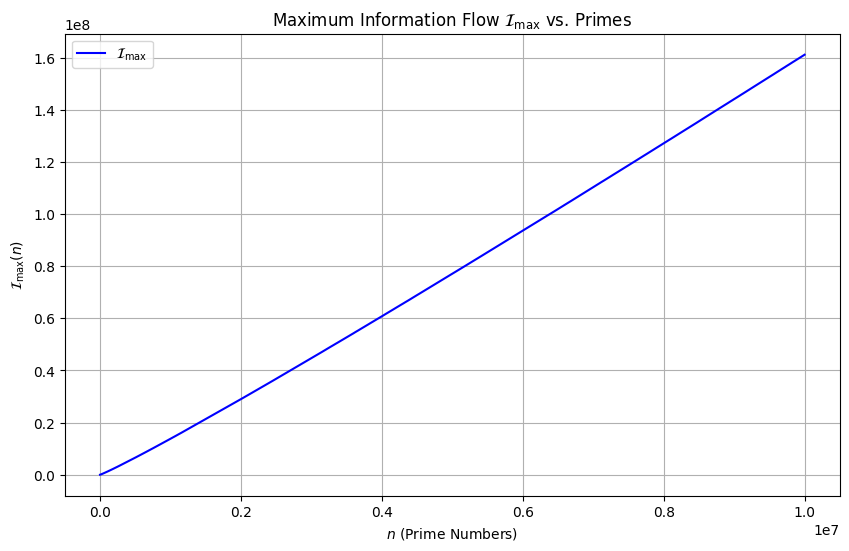

In [18]:
import matplotlib.pyplot as plt

# Plot I_max
plt.figure(figsize=(10, 6))
plt.plot(n_values, imax_values, label='$\mathcal{I}_{\\text{max}}$', color='blue')
plt.xlabel('$n$ (Prime Numbers)')
plt.ylabel('$\mathcal{I}_{\\text{max}}(n)$')
plt.title('Maximum Information Flow $\mathcal{I}_{\\text{max}}$ vs. Primes')
plt.legend()
plt.grid()
plt.show()


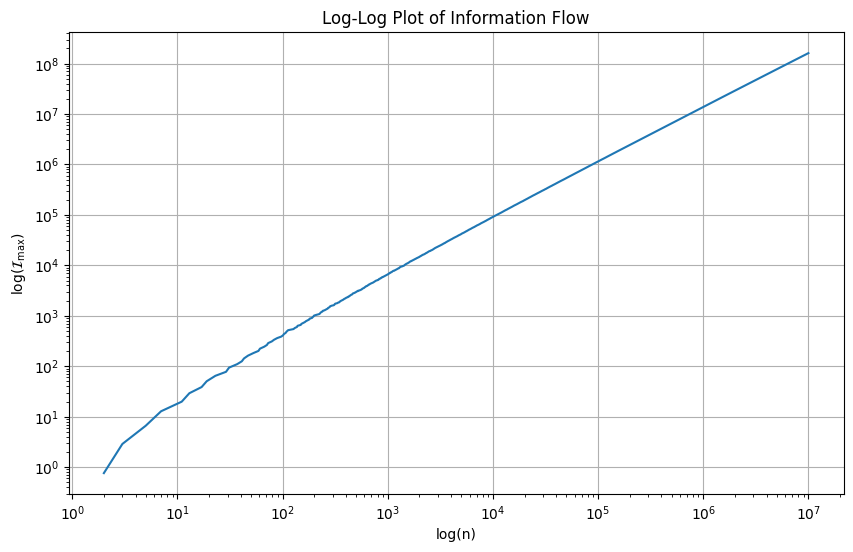

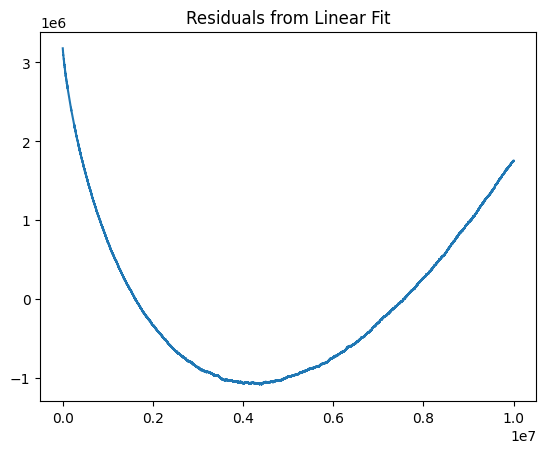

In [19]:
# Log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(n_values, imax_values, label='$\mathcal{I}_{\\text{max}}$')
plt.xlabel('log(n)')
plt.ylabel('log($\mathcal{I}_{\\text{max}}$)')
plt.title('Log-Log Plot of Information Flow')
plt.grid(True)
plt.show()

# Examine residuals
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(n_values, imax_values)
residuals = imax_values - (slope * n_values + intercept)
plt.plot(n_values, residuals)
plt.title('Residuals from Linear Fit')
plt.show()

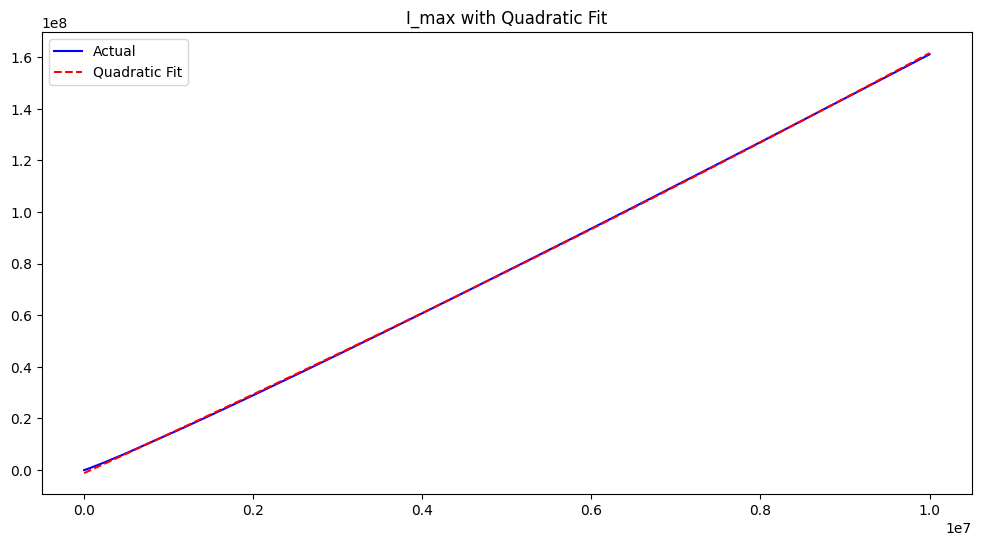

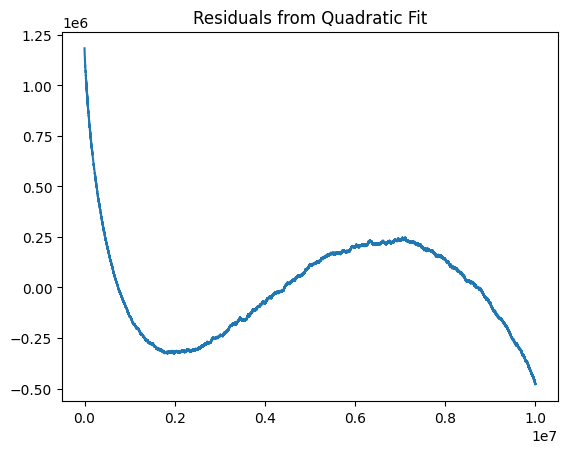

In [20]:
# Fit a quadratic function
from numpy.polynomial.polynomial import polyfit
coeffs = polyfit(n_values, imax_values, 2)
quad_fit = coeffs[0] + coeffs[1]*n_values + coeffs[2]*n_values**2

# Plot original and fit
plt.figure(figsize=(12,6))
plt.plot(n_values, imax_values, 'b-', label='Actual')
plt.plot(n_values, quad_fit, 'r--', label='Quadratic Fit')
plt.title('I_max with Quadratic Fit')
plt.legend()
plt.show()

# Look at residuals from quadratic fit
quad_residuals = imax_values - quad_fit
plt.plot(n_values, quad_residuals)
plt.title('Residuals from Quadratic Fit')
plt.show()

In [23]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 2.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 2.9 MB/s eta 0:00:003.0 MB/s eta 0:00:01

[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [24]:
# Calculate fit accuracy
from sklearn.metrics import r2_score
r2 = r2_score(imax_values, quad_fit)
print(f"R² score: {r2}")

# Look at percentage deviation
percent_diff = 100 * (quad_fit - imax_values) / imax_values
print(f"Mean percentage difference: {np.mean(abs(percent_diff))}%")

R² score: 0.9999709361081666
Mean percentage difference: 403.167352463221%


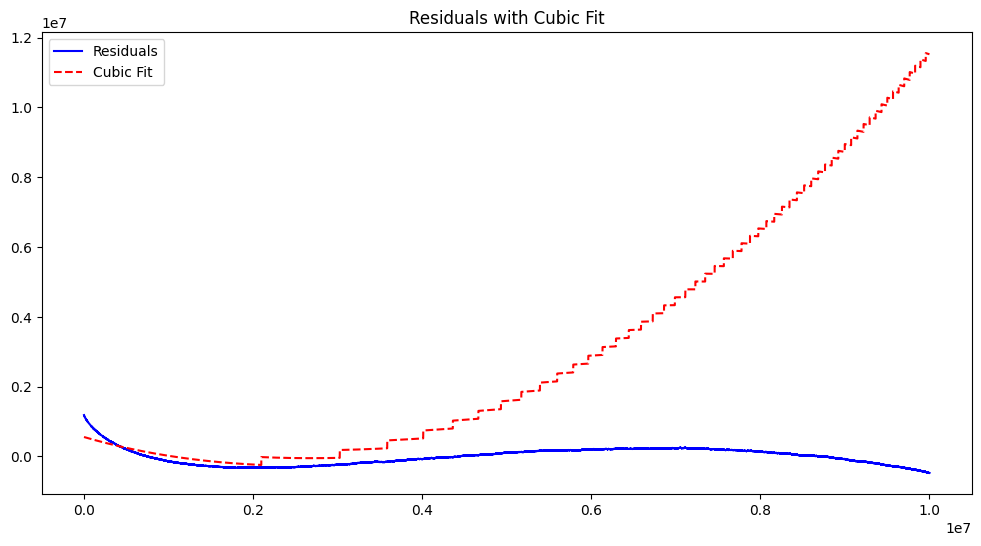

In [25]:
# Fit cubic to residuals
cubic_coeffs = polyfit(n_values, quad_residuals, 3)
cubic_fit = cubic_coeffs[0] + cubic_coeffs[1]*n_values + cubic_coeffs[2]*n_values**2 + cubic_coeffs[3]*n_values**3

# Plot original residuals and cubic fit
plt.figure(figsize=(12,6))
plt.plot(n_values, quad_residuals, 'b-', label='Residuals')
plt.plot(n_values, cubic_fit, 'r--', label='Cubic Fit')
plt.title('Residuals with Cubic Fit')
plt.legend()
plt.show()

Mean absolute difference: 204712.20769802987


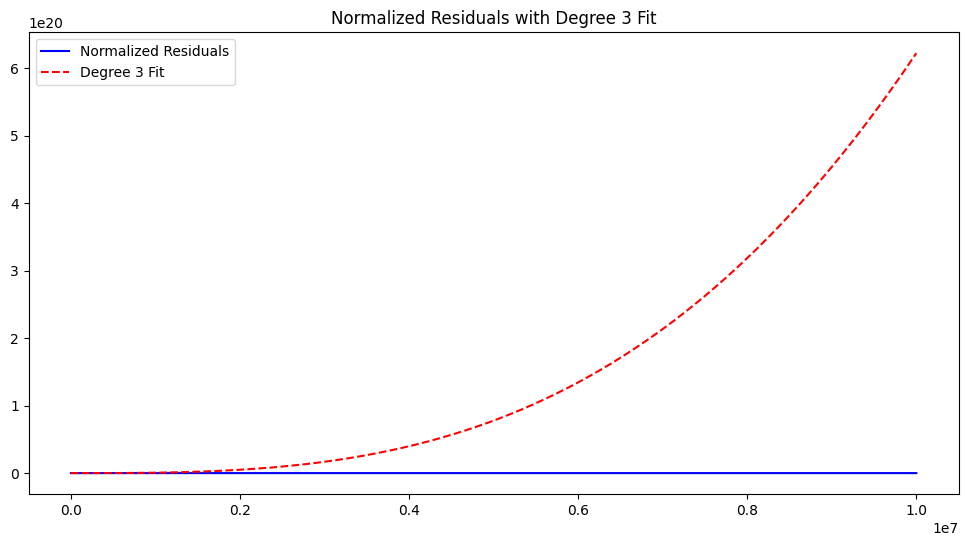

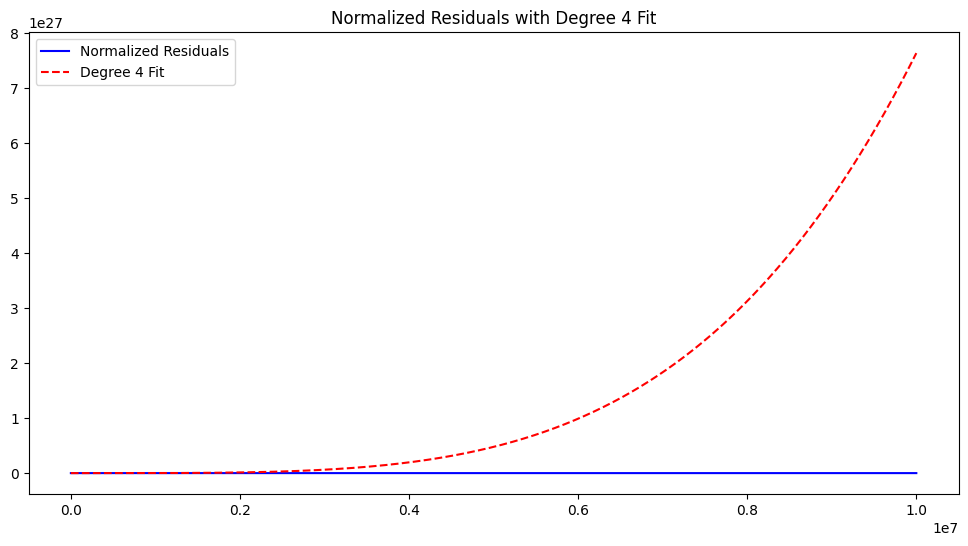

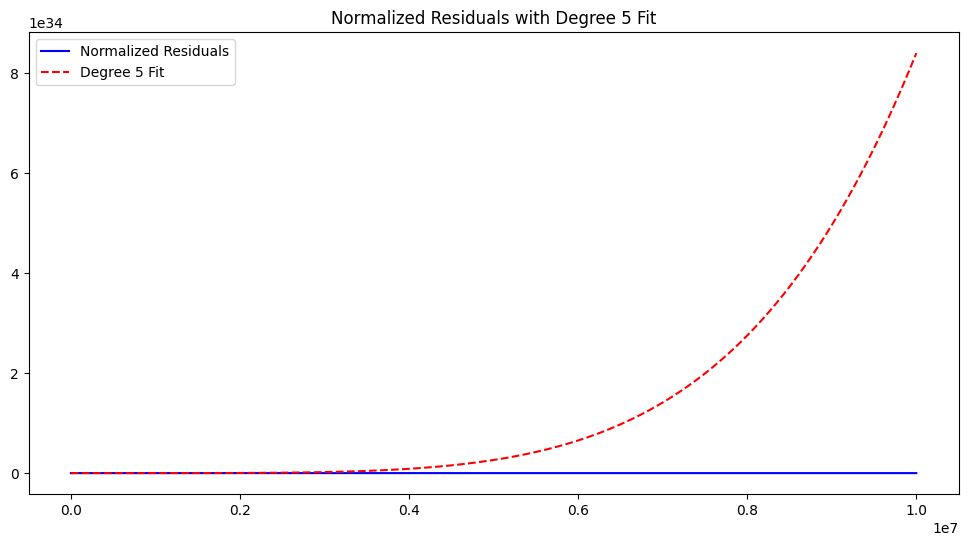

In [26]:
# Look at absolute differences instead of percentages
abs_diff = np.abs(quad_fit - imax_values)
print(f"Mean absolute difference: {np.mean(abs_diff)}")

# Maybe normalize the residuals first
normalized_residuals = (quad_residuals - np.min(quad_residuals)) / (np.max(quad_residuals) - np.min(quad_residuals))

# Try polynomial fits of different orders
for degree in [3, 4, 5]:
    coeffs = polyfit(n_values, normalized_residuals, degree)
    fit = np.polyval(coeffs, n_values)
    plt.figure(figsize=(12,6))
    plt.plot(n_values, normalized_residuals, 'b-', label='Normalized Residuals')
    plt.plot(n_values, fit, 'r--', label=f'Degree {degree} Fit')
    plt.title(f'Normalized Residuals with Degree {degree} Fit')
    plt.legend()
    plt.show()

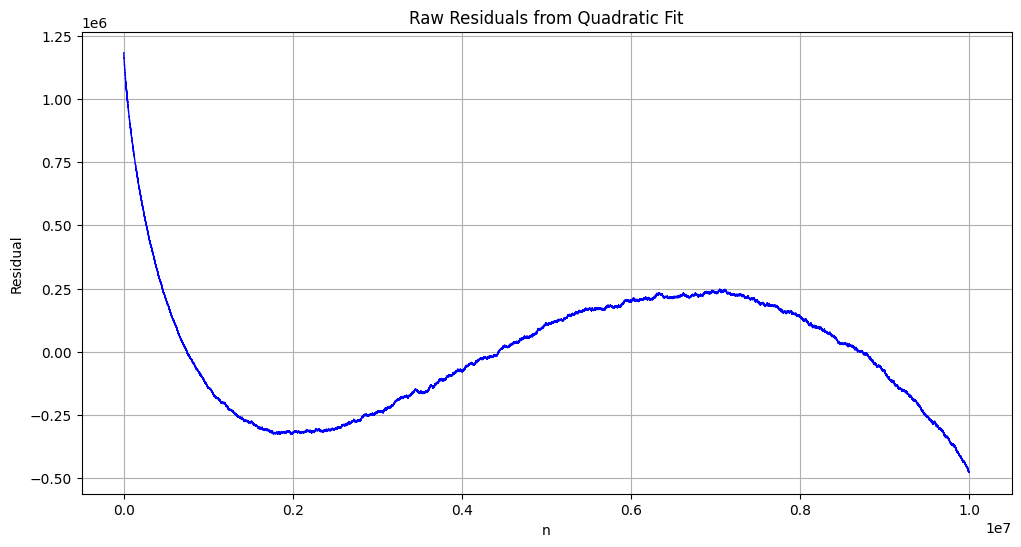

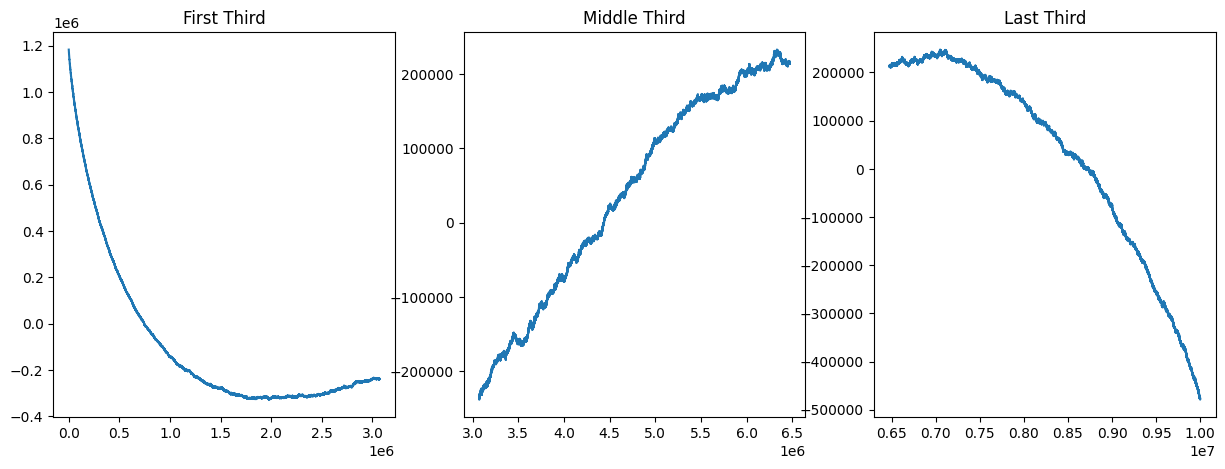

In [27]:
# Just plot the raw residuals again, cleaned up
plt.figure(figsize=(12,6))
plt.plot(n_values, quad_residuals, 'b-', linewidth=1)
plt.title('Raw Residuals from Quadratic Fit')
plt.xlabel('n')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

# Maybe look at different sections
# Split into thirds and plot separately
split1 = len(n_values)//3
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.plot(n_values[:split1], quad_residuals[:split1])
plt.title('First Third')
plt.subplot(132)
plt.plot(n_values[split1:2*split1], quad_residuals[split1:2*split1])
plt.title('Middle Third')
plt.subplot(133)
plt.plot(n_values[2*split1:], quad_residuals[2*split1:])
plt.title('Last Third')
plt.show()

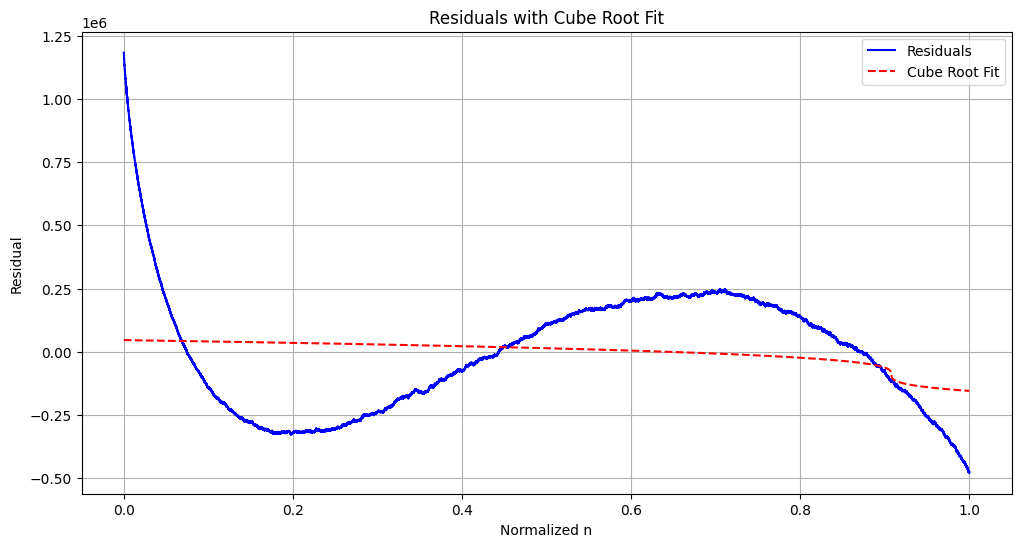

Fit parameters: a=-141526.47805341292, b=0.9080101265958107, c=-91132.36665217097


In [28]:
# Try cube root fit to residuals
def cube_root_fit(x, a, b, c):
    return a * np.cbrt(x - b) + c

from scipy.optimize import curve_fit

# Normalize x values to 0-1 range for better fitting
x_norm = (n_values - np.min(n_values)) / (np.max(n_values) - np.min(n_values))

try:
    # Fit cube root function to residuals
    popt, _ = curve_fit(cube_root_fit, x_norm, quad_residuals)
    
    # Plot original residuals and cube root fit
    plt.figure(figsize=(12,6))
    plt.plot(x_norm, quad_residuals, 'b-', label='Residuals')
    plt.plot(x_norm, cube_root_fit(x_norm, *popt), 'r--', label='Cube Root Fit')
    plt.title('Residuals with Cube Root Fit')
    plt.xlabel('Normalized n')
    plt.ylabel('Residual')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Fit parameters: a={popt[0]}, b={popt[1]}, c={popt[2]}")
except:
    print("Fitting failed, might need to adjust initial parameters")

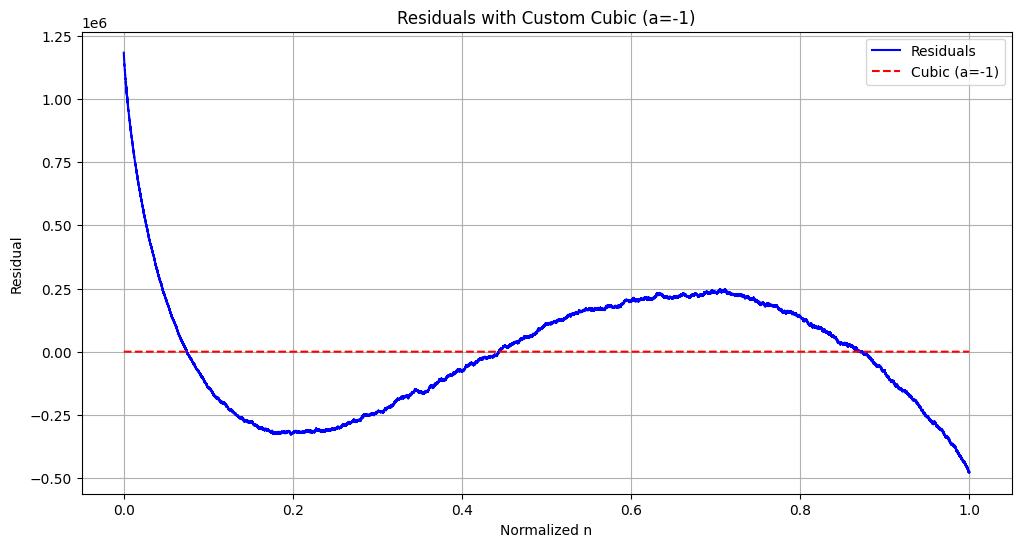

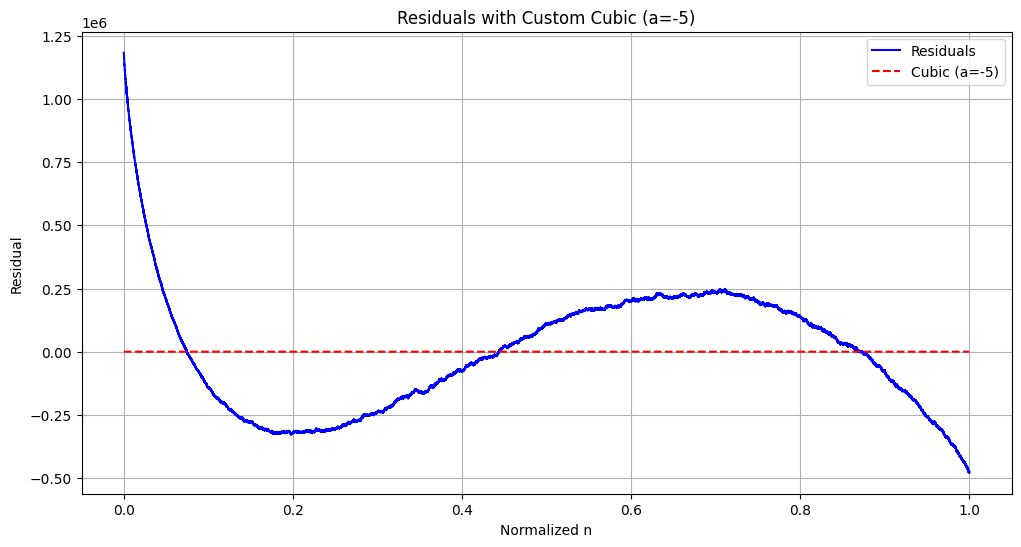

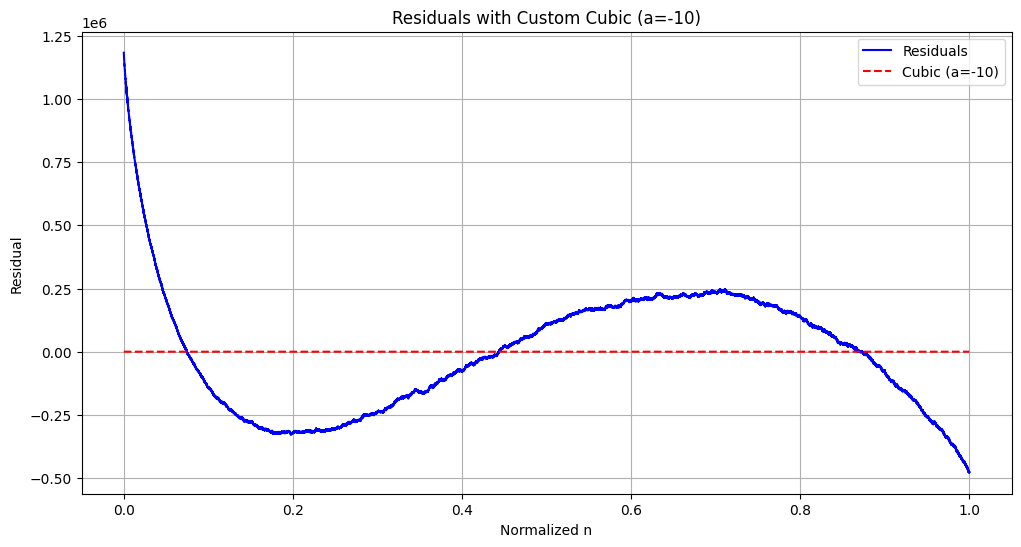

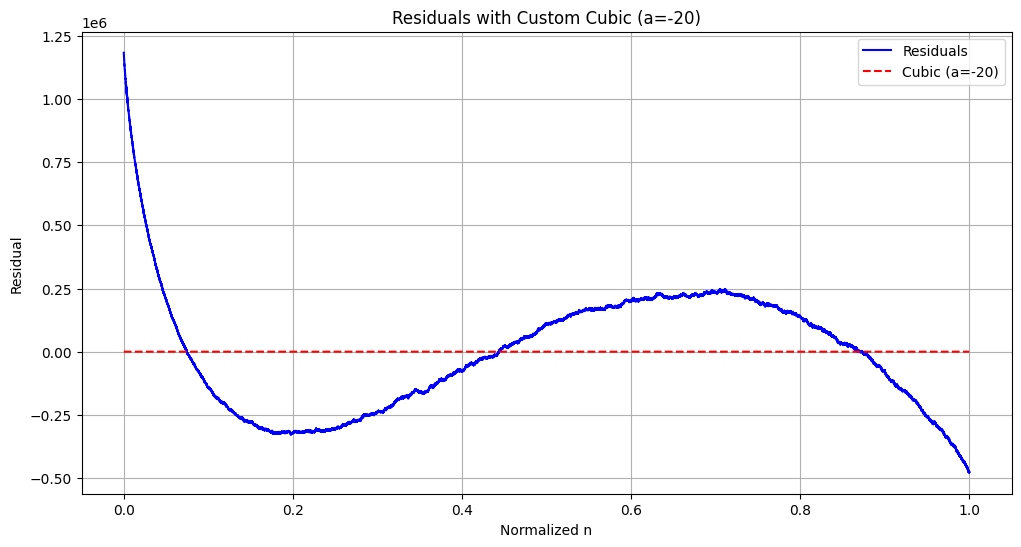

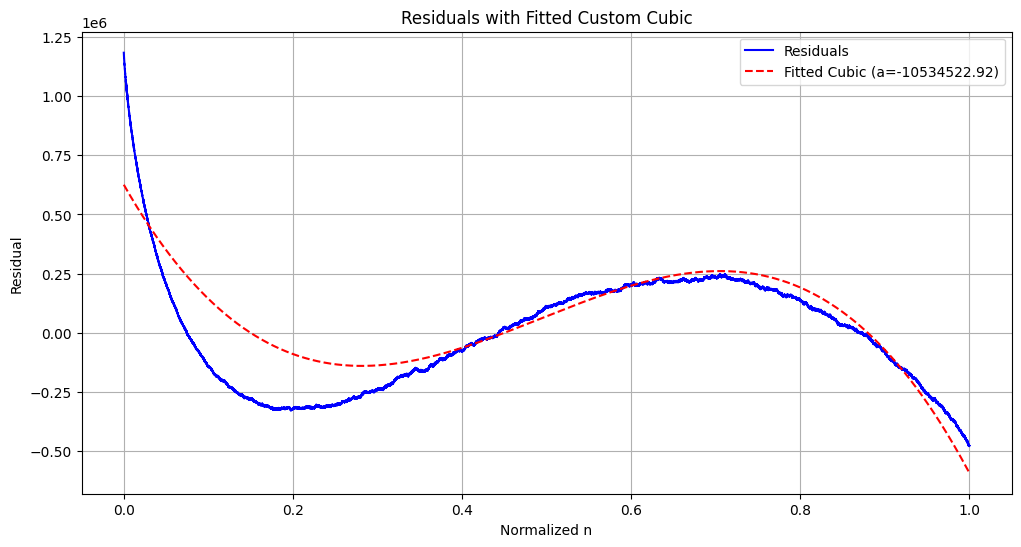

In [29]:
# Create cubic function with specified roots
def custom_cubic(x, a):
    # Roots at 0.15, 0.45, and 0.88
    return a * (x - 0.15) * (x - 0.45) * (x - 0.88)

# Try different values of 'a' (negative to trend down)
for a in [-1, -5, -10, -20]:
    plt.figure(figsize=(12,6))
    plt.plot(x_norm, quad_residuals, 'b-', label='Residuals')
    plt.plot(x_norm, custom_cubic(x_norm, a), 'r--', label=f'Cubic (a={a})')
    plt.title(f'Residuals with Custom Cubic (a={a})')
    plt.xlabel('Normalized n')
    plt.ylabel('Residual')
    plt.legend()
    plt.grid(True)
    plt.show()

# Or let's try fitting 'a' automatically
try:
    def fit_func(x, a):
        return custom_cubic(x, a)
    
    popt, _ = curve_fit(fit_func, x_norm, quad_residuals)
    a_fit = popt[0]
    
    plt.figure(figsize=(12,6))
    plt.plot(x_norm, quad_residuals, 'b-', label='Residuals')
    plt.plot(x_norm, custom_cubic(x_norm, a_fit), 'r--', label=f'Fitted Cubic (a={a_fit:.2f})')
    plt.title('Residuals with Fitted Custom Cubic')
    plt.xlabel('Normalized n')
    plt.ylabel('Residual')
    plt.legend()
    plt.grid(True)
    plt.show()
except:
    print("Fitting failed, might need to adjust approach")

Zero crossings at x = [0.07440744 0.44374437 0.86788679 0.8679868  0.87038704 0.87048705
 0.87088709 0.87118712 0.87168717 0.87178718 0.87228723 0.87238724
 0.87278728 0.87308731 0.87348735]


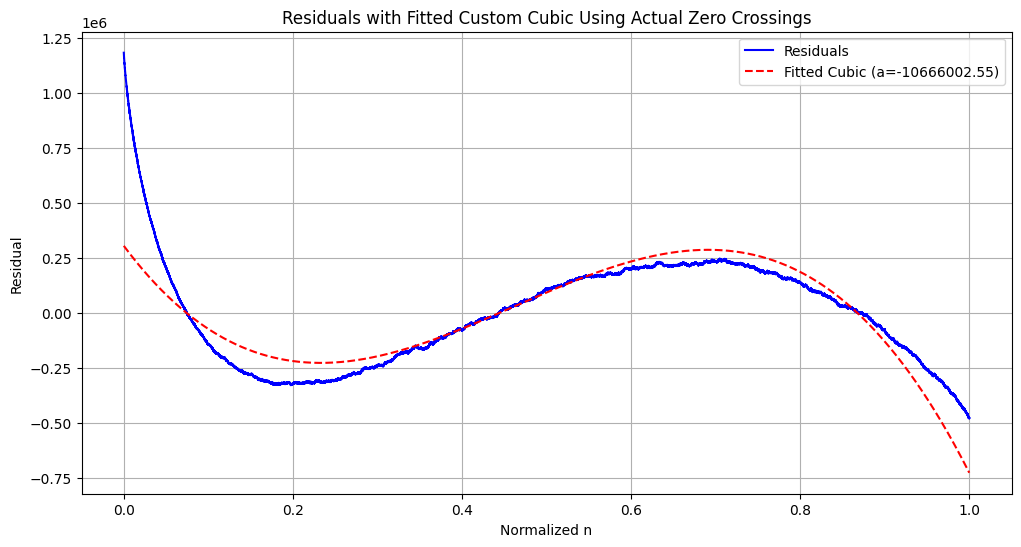

In [30]:
# Find where residuals cross zero
# First interpolate to get more precise crossings
from scipy.interpolate import interp1d

f = interp1d(x_norm, quad_residuals, kind='linear')
x_dense = np.linspace(np.min(x_norm), np.max(x_norm), 10000)
y_dense = f(x_dense)

# Find zero crossings
zero_crossings = x_dense[np.where(np.diff(np.signbit(y_dense)))[0]]
print("Zero crossings at x =", zero_crossings)

# Now create cubic with actual zero crossings
def custom_cubic_actual(x, a):
    return a * (x - zero_crossings[0]) * (x - zero_crossings[1]) * (x - zero_crossings[2])

# Fit with actual zero crossings
popt, _ = curve_fit(lambda x, a: custom_cubic_actual(x, a), x_norm, quad_residuals)
a_fit = popt[0]

plt.figure(figsize=(12,6))
plt.plot(x_norm, quad_residuals, 'b-', label='Residuals')
plt.plot(x_norm, custom_cubic_actual(x_norm, a_fit), 'r--', 
         label=f'Fitted Cubic (a={a_fit:.2f})')
plt.title('Residuals with Fitted Custom Cubic Using Actual Zero Crossings')
plt.xlabel('Normalized n')
plt.ylabel('Residual')
plt.legend()
plt.grid(True)
plt.show()